# 07. Simulator Observable Adapter Validation

本 notebook 解除 04 中的**代码路径不清楚**问题，但不把 cortical firing rate 改名为 simulated EEG。adapter 的输入是现有 V7/V8/V8a 模型的 `r_mean_EXC`，经项目既有的 `*1000` 换算为 Hz；它只能称为 **cortical excitatory firing-rate proxy**。

科学边界：真实数据是 Fpz-Cz scalp EEG（uV）。没有 forward model、reference model 或 uV calibration，因此即使相同的 Python feature function 可以执行，也不等于 observation semantic parity，更不能开始 SNPE。

## Environment and protected scope

此处只读取已有 simulator 与真实 observation 代码。不会修改 V7/V8/V8a 模型机制、real-EEG thresholds、filters 或既有 notebooks；输出也不保存完整 firing-rate arrays。

In [1]:
from __future__ import annotations
import json
import os
from pathlib import Path
import platform
import sys
import time

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / '.git').exists() and (PROJECT_ROOT / 'S4_sbi').exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Could not locate repository root')
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / 'S4_sbi' / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from sleep_sbi import overnight_ablation as oa
from sleep_sbi import simulator_observable_adapter as adapter
from sleep_sbi.observation import load_observation_config

OUTPUT_DIR = PROJECT_ROOT / 'S4_sbi' / 'results' / 'simulator_observable_adapter_validation'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG = load_observation_config()
ENVIRONMENT = {
    'conda_environment': os.environ.get('CONDA_DEFAULT_ENV'),
    'sys_executable': sys.executable,
    'sys_prefix': sys.prefix,
    'python': sys.version,
    'platform': platform.platform(),
    'kernel_id': 'python3',
    'kernel_display_name': 'neurolib',
    'output_dir': str(OUTPUT_DIR.relative_to(PROJECT_ROOT)).replace('\\', '/'),
}
assert ENVIRONMENT['conda_environment'] == 'neurolib'
assert 'neurolib' in ENVIRONMENT['sys_executable'].lower()
display(pd.DataFrame([ENVIRONMENT]))


,conda_environment,sys_executable,sys_prefix,python,platform,kernel_id,kernel_display_name,output_dir
0,neurolib,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...,C:\Users\YUS190\AppData\Local\anaconda3\envs\n...,"3.10.20 | packaged by conda-forge | (main, Mar...",Windows-10-10.0.19045-SP0,python3,neurolib,S4_sbi/results/simulator_observable_adapter_va...


## Audit: what signal did historical real-vs-model comparisons use?

`simulator_wrapper.py` 和 V7/V8 fitness 都从 `r_mean_EXC` 取 cortex index 0，并将 kHz output 乘以 1000 转为 Hz。模型以 `sampling_dt=1 ms` 输出、总时长 60 s，丢弃 5 s warm-up。它是 population firing-rate state observable，而不是 EEG proxy。

In [2]:
wrapper_text = (PROJECT_ROOT / 'S4_sbi' / 'simulator_wrapper.py').read_text(encoding='utf-8', errors='replace')
v7_text = (PROJECT_ROOT / 'models' / 's4_personalize_fig7_v7.py').read_text(encoding='utf-8', errors='replace')
v8_text = (PROJECT_ROOT / 'models' / 's4_personalize_fig7_v8.py').read_text(encoding='utf-8', errors='replace')
audit = pd.DataFrame([
    {'source': 'simulator_wrapper.py', 'r_mean_EXC': 'r_mean_EXC' in wrapper_text, 'kHz_to_Hz': '* 1000.0' in wrapper_text, 'warm_up_5_s': '5.0 * _FS' in wrapper_text, 'declares_EEG_proxy': 'simulated EEG' in wrapper_text.lower()},
    {'source': 'V7 fitting', 'r_mean_EXC': 'r_mean_' in v7_text, 'kHz_to_Hz': '* 1000.0' in v7_text, 'warm_up_5_s': '5.0 * FS_SIM' in v7_text, 'declares_EEG_proxy': False},
    {'source': 'V8/V8a fitting', 'r_mean_EXC': 'r_mean_' in v8_text, 'kHz_to_Hz': '* 1000.0' in v8_text, 'warm_up_5_s': '5.0 * FS_SIM' in v8_text, 'declares_EEG_proxy': False},
])
display(audit)
display(pd.DataFrame([{
    'real_signal': 'EEG Fpz-Cz', 'real_unit': 'uV',
    'simulator_signal': adapter.RATE_PROXY_SIGNAL, 'simulator_unit': adapter.RATE_PROXY_UNIT,
    'simulation_fs_hz': 1000.0, 'simulation_duration_s': 60.0, 'warm_up_removed_s': adapter.WARM_UP_S,
    'real_epoch_duration_s': CONFIG.epoch_duration_s, 'real_so_half_wave_threshold_uV': CONFIG.so_half_wave_uv,
    'interpretation': 'No physical forward/reference mapping is implemented.'
}]))


,source,r_mean_EXC,kHz_to_Hz,warm_up_5_s,declares_EEG_proxy
0,simulator_wrapper.py,False,True,True,False
1,V7 fitting,True,True,True,False
2,V8/V8a fitting,True,True,True,False


,real_signal,real_unit,simulator_signal,simulator_unit,simulation_fs_hz,simulation_duration_s,warm_up_removed_s,real_epoch_duration_s,real_so_half_wave_threshold_uV,interpretation
0,EEG Fpz-Cz,uV,cortical excitatory population firing rate proxy,Hz,1000.0,60.0,5.0,30.0,75.0,No physical forward/reference mapping is imple...


## Adapter contract

`minimal_spectral_so_proxy4` 使用与真实 EEG 相同的 Welch、spectral statistic 与 FOOOF 函数。这些统计量对正比例振幅缩放较不敏感，但仍只满足 algorithm-level execution，不满足 scalp channel semantics。SO morphology 被显式阻断，因为 real detector 的 75 uV half-wave threshold 不能应用于 Hz。Spindle 与 PAC 函数会执行以暴露 code-level support；它们仍只作为 proxy diagnostics。

In [3]:
schema_inventory = pd.DataFrame([
    {'schema': name, 'dimension': len(features), 'feature_names': ', '.join(features)}
    for name, features in adapter.SCHEMA_FEATURES.items()
])
display(schema_inventory)
print('SO detector threshold remains in real EEG units:', CONFIG.so_half_wave_uv, 'uV')
print('Spindle band:', CONFIG.spindle_band_hz, 'Hz; PAC bands:', CONFIG.pac_phase_band_hz, CONFIG.pac_amplitude_band_hz)


,schema,dimension,feature_names
0,minimal_spectral_so_proxy4,4,"fooof_aperiodic_exponent, so_peak_frequency_hz..."
1,minimal_plus_so_morphology7,7,"fooof_aperiodic_exponent, so_peak_frequency_hz..."
2,minimal_plus_spindle6,6,"fooof_aperiodic_exponent, so_peak_frequency_hz..."
3,minimal_plus_pac9,9,"fooof_aperiodic_exponent, so_peak_frequency_hz..."
4,baseline14,14,"fooof_aperiodic_exponent, so_peak_frequency_hz..."


SO detector threshold remains in real EEG units: 75.0 uV
Spindle band: (11.0, 15.0) Hz; PAC bands: (0.5, 1.5) (10.0, 14.0)


## End-to-end debug: V7 fitted

先运行一个参数点，检查 model import、warm-up removal、30 s segmentation、FOOOF 与 validity ledger。成功只表示 adapter path 可执行，不表示 V7 cortical rate 已成为 simulated EEG。

In [4]:
representatives = adapter.load_representative_parameter_sets()
debug_result = adapter.run_adapter(representatives[0], config=CONFIG)
assert debug_result.success, debug_result.failure_reason
debug_features, debug_schemas, debug_run = adapter.result_rows(debug_result)
display(debug_run)
display(debug_features[['feature', 'value', 'valid', 'support', 'failure_reason', 'semantic_status']])
display(debug_schemas[['schema', 'dimension', 'record_vector_finite', 'algorithm_level_available', 'semantic_parity_pass', 'semantic_status']])
assert debug_result.n_complete_30s_epochs == 1
assert debug_result.discarded_tail_s == 25.0


D:\Year3_Mao_Projects\sleep_loop\models\s4_personalize_fig7_v7.py:138: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


,identifier,model_version,source,success,runtime_s,simulation_duration_s,warm_up_removed_s,active_duration_s,discarded_tail_s,fs_hz,proxy_signal,proxy_unit,n_complete_30s_epochs,failure_reason,parameters_json,warnings_json
0,v7_fitted,v7,data/patient_params_fig7_v7_SC4001.json,True,9.085699,60.0,5.0,55.0,25.0,1000.0,cortical excitatory population firing rate proxy,Hz,1,None,"{""b"": 42.54812807491384, ""c_ctx2th"": 0.0562265...","[""backend=numba"", ""Cortical firing rate is a m..."


,feature,value,valid,support,failure_reason,semantic_status
0,fooof_aperiodic_exponent,0.703448,True,1,None,same_algorithm_proxy_only
1,so_peak_frequency_hz,1.250000,True,1,None,same_algorithm_proxy_only
2,relative_so_power,0.365458,True,1,None,same_algorithm_proxy_only
3,so_q,4.382125,True,1,None,same_algorithm_proxy_only
4,so_event_rate_per_min,NaN,False,0,blocked_unit_dependent_real_EEG_detector_thres...,blocked_unit_mismatch
5,ibi_cv,NaN,False,0,blocked_unit_dependent_real_EEG_detector_thres...,blocked_unit_mismatch
6,pac_up_down_ratio,3.671778,True,1,None,same_algorithm_proxy_only
7,spindle_density_per_min,0.000000,True,0,None,same_algorithm_proxy_only
8,spindle_mean_duration_s,NaN,False,0,no_detected_spindle_events,proxy_event_support_insufficient
9,pac_mi,0.092071,True,1,None,same_algorithm_proxy_only


,schema,dimension,record_vector_finite,algorithm_level_available,semantic_parity_pass,semantic_status
0,minimal_spectral_so_proxy4,4,True,True,False,NO-GO: cortical firing-rate proxy is not a val...
1,minimal_plus_so_morphology7,7,False,False,False,NO-GO: includes unit-dependent or undefined pr...
2,minimal_plus_spindle6,6,False,False,False,NO-GO: includes unit-dependent or undefined pr...
3,minimal_plus_pac9,9,True,True,False,NO-GO: cortical firing-rate proxy is not a val...
4,baseline14,14,False,False,False,NO-GO: includes unit-dependent or undefined pr...


## Representative validation batch with per-candidate checkpoints

继续运行 V8 fitted、V8a local best 与三个 V8a near-feasible candidates。每完成一个点，adapter 会覆盖写入小型 summary/validity CSV；不会保存完整 rate arrays。

In [5]:
results = adapter.run_validation_batch(
    OUTPUT_DIR,
    parameter_sets=representatives[1:],
    completed_results=[debug_result],
    config=CONFIG,
)
run_summary = pd.read_csv(OUTPUT_DIR / 'adapter_run_summary.csv')
feature_matrix = pd.read_csv(OUTPUT_DIR / 'adapter_feature_matrix.csv')
schema_status = pd.read_csv(OUTPUT_DIR / 'adapter_schema_status.csv')
assert len(run_summary) == 6
display(run_summary[['identifier', 'model_version', 'success', 'runtime_s', 'fs_hz', 'active_duration_s', 'discarded_tail_s', 'failure_reason']])


,identifier,model_version,success,runtime_s,fs_hz,active_duration_s,discarded_tail_s,failure_reason
0,v7_fitted,v7,True,9.085699,1000.0,55.0,25.0,NaN
1,v8_fitted,v8,True,4.851354,1000.0,55.0,25.0,NaN
2,v8a_local_best,v8a_t13,True,4.673378,1000.0,55.0,25.0,NaN
3,v8a_near_feasible_seed_000,v8a_t13,True,4.720457,1000.0,55.0,25.0,NaN
4,v8a_near_feasible_seed_001,v8a_t13,True,4.732724,1000.0,55.0,25.0,NaN
5,v8a_near_feasible_seed_002,v8a_t13,True,4.883541,1000.0,55.0,25.0,NaN


## Feature-level blocker matrix and maximum defensible schema

这里同时显示 algorithm availability 和 semantic parity。任何 row 的 `semantic_parity_pass=False` 都不能进入 SNPE。这避免把从 r_mean_EXC 计算出来的数值误写成 EEG observation。

In [6]:
comparison = oa.load_schema_comparison()
real_support = comparison['support'].rename(columns={'feature_name': 'feature', 'valid_epoch_count': 'real_valid_epochs'})
feature_summary = (feature_matrix.groupby(['feature', 'semantic_status', 'failure_reason'], dropna=False)
                   .agg(proxy_valid_candidates=('valid', 'sum'), proxy_candidate_count=('candidate_id', 'nunique'), median_proxy_value=('value', 'median'))
                   .reset_index())
blocker_matrix = feature_summary.merge(real_support[['feature', 'real_valid_epochs', 'most_common_invalid_reason']], on='feature', how='left')
blocker_matrix['parity_decision'] = np.where(
    blocker_matrix['semantic_status'].eq('same_algorithm_proxy_only'),
    'NO-GO: rate proxy lacks validated scalp-EEG mapping',
    'NO-GO: unit-dependent detector or event support blocker',
)
blocker_matrix.to_csv(OUTPUT_DIR / 'feature_level_blocker_matrix.csv', index=False)
display(blocker_matrix)
schema_overview = (schema_status.groupby('schema', as_index=False)
                   .agg(dimension=('dimension', 'first'), candidates=('candidate_id', 'nunique'), all_record_vectors_finite=('record_vector_finite', 'all'), all_algorithm_available=('algorithm_level_available', 'all'), semantic_parity_pass=('semantic_parity_pass', 'all'), status=('semantic_status', 'first')))
display(schema_overview)
assert not schema_overview['semantic_parity_pass'].any()


,feature,semantic_status,failure_reason,proxy_valid_candidates,proxy_candidate_count,median_proxy_value,real_valid_epochs,most_common_invalid_reason,parity_decision
0,fooof_aperiodic_exponent,same_algorithm_proxy_only,NaN,6,6,0.970035,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
1,ibi_cv,blocked_unit_mismatch,blocked_unit_dependent_real_EEG_detector_thres...,0,6,NaN,124,fewer_than_three_so_events,NO-GO: unit-dependent detector or event suppor...
2,pac_mi,same_algorithm_proxy_only,NaN,6,6,0.071490,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
3,pac_preferred_phase_cos,same_algorithm_proxy_only,NaN,6,6,0.866025,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
4,pac_preferred_phase_rad,same_algorithm_proxy_only,NaN,6,6,-0.523599,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
5,pac_preferred_phase_sin,same_algorithm_proxy_only,NaN,6,6,-0.500000,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
6,pac_up_down_ratio,same_algorithm_proxy_only,NaN,6,6,2.871814,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
7,relative_so_power,same_algorithm_proxy_only,NaN,6,6,0.350797,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...
8,so_event_rate_per_min,blocked_unit_mismatch,blocked_unit_dependent_real_EEG_detector_thres...,0,6,NaN,142,none/not applicable,NO-GO: unit-dependent detector or event suppor...
9,so_peak_frequency_hz,same_algorithm_proxy_only,NaN,6,6,1.250000,142,none/not applicable,NO-GO: rate proxy lacks validated scalp-EEG ma...


,schema,dimension,candidates,all_record_vectors_finite,all_algorithm_available,semantic_parity_pass,status
0,baseline14,14,6,False,False,False,NO-GO: includes unit-dependent or undefined pr...
1,minimal_plus_pac9,9,6,True,True,False,NO-GO: cortical firing-rate proxy is not a val...
2,minimal_plus_so_morphology7,7,6,False,False,False,NO-GO: includes unit-dependent or undefined pr...
3,minimal_plus_spindle6,6,6,False,False,False,NO-GO: includes unit-dependent or undefined pr...
4,minimal_spectral_so_proxy4,4,6,True,True,False,NO-GO: cortical firing-rate proxy is not a val...


## Real EEG versus cortical-rate proxy: ranges and support

图仅用于发现明显 range/support 问题。不同面板保留各自 y-axis，不能将 rate proxy 与 EEG 的绝对幅度直接解释为同一物理量。

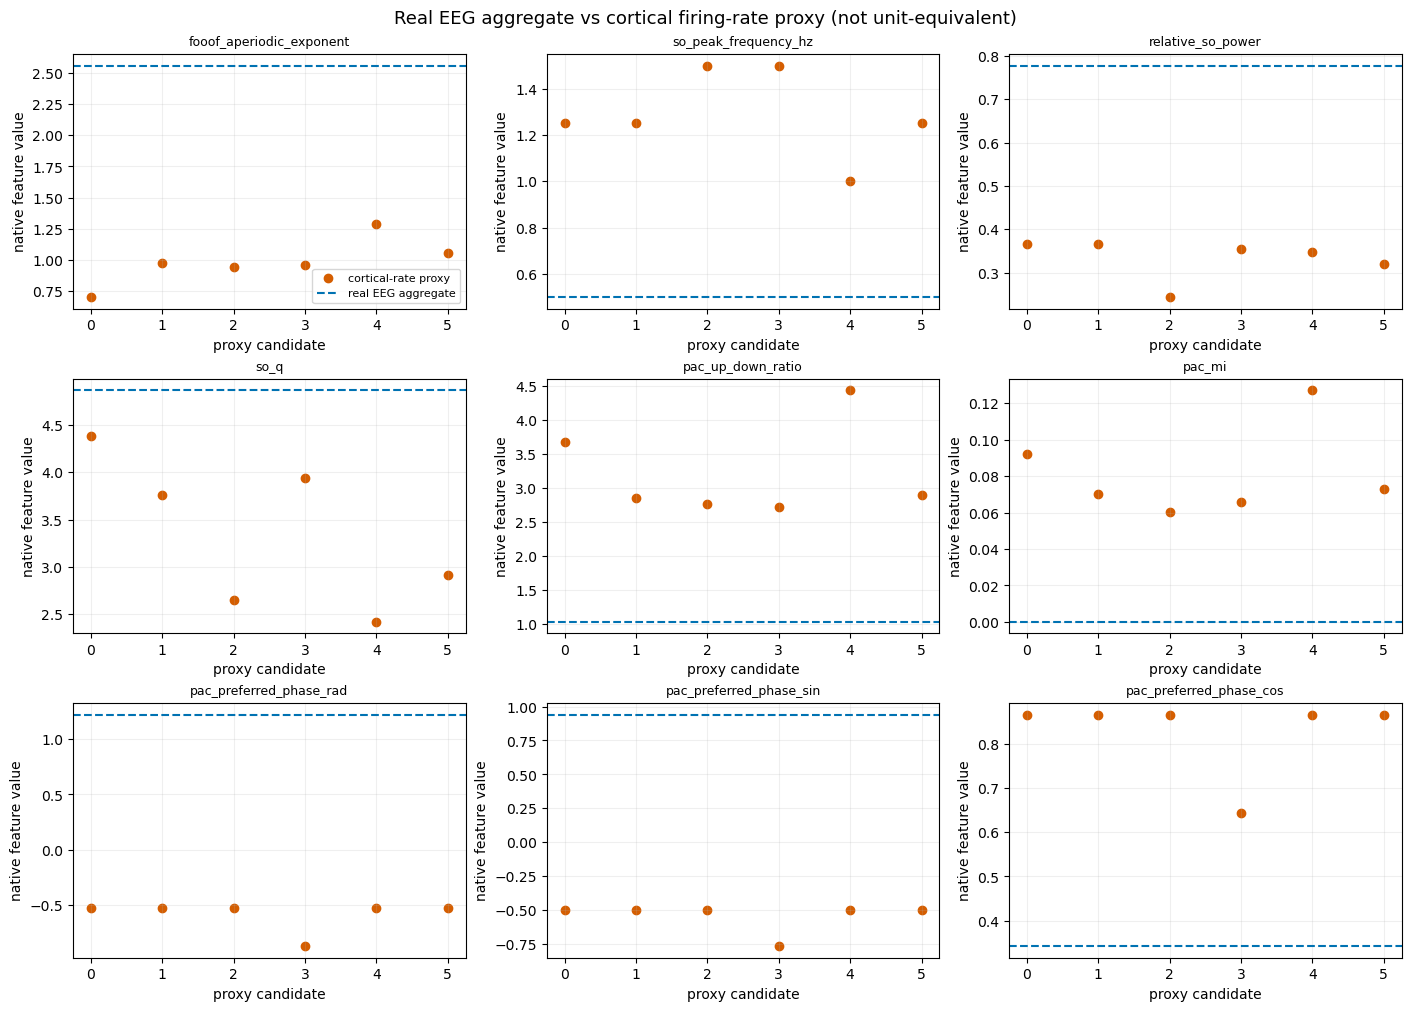

In [7]:
real_values = dict(zip(comparison['baseline_names'], comparison['vectors']['x_o_baseline']))
plot_features = list(adapter.SPECTRAL_SO_PROXY_FEATURES + adapter.PAC_FEATURES)
fig, axes = plt.subplots(3, 3, figsize=(14, 10), constrained_layout=True)
for ax, feature in zip(axes.flat, plot_features):
    proxy = feature_matrix.loc[feature_matrix['feature'].eq(feature) & feature_matrix['valid'], 'value'].dropna().to_numpy()
    if len(proxy):
        ax.scatter(np.arange(len(proxy)), proxy, color='#d55e00', label='cortical-rate proxy')
    if feature in real_values and np.isfinite(real_values[feature]):
        ax.axhline(real_values[feature], color='#0072b2', linestyle='--', label='real EEG aggregate')
    ax.set_title(feature, fontsize=9)
    ax.set_xlabel('proxy candidate')
    ax.set_ylabel('native feature value')
    ax.grid(alpha=0.2)
    if ax is axes.flat[0]:
        ax.legend(fontsize=8)
for ax in axes.flat[len(plot_features):]:
    ax.axis('off')
fig.suptitle('Real EEG aggregate vs cortical firing-rate proxy (not unit-equivalent)', fontsize=13)
fig.savefig(OUTPUT_DIR / 'real_vs_cortical_proxy_ranges.png', dpi=160, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'real_vs_cortical_proxy_ranges.svg', bbox_inches='tight')
display(fig)
plt.close(fig)


## Gate decision, no mini bank, and artifact reload

只有 `semantic_parity_pass=True` 的 fixed-length schema 才能生成 simulation bank。当前无 schema 通过，所以不保存 mini bank，也不启动 SNPE。此处把 blocker 写成可恢复的最小后续工作。

In [8]:
approved = schema_overview.loc[schema_overview['semantic_parity_pass'] & schema_overview['all_record_vectors_finite']]
gate = {
    'status': 'NO-GO' if approved.empty else 'GO',
    'approved_schemas': approved['schema'].tolist(),
    'mini_bank_created': False,
    'snpe_started': False,
    'minimum_next_step': 'Define and validate a forward/reference mapping from model cortical observables to the declared EEG Fpz-Cz observable; then freeze units, epochs, aggregation, validity, and scaling before rerunning parity.',
    'reviewer_note': 'Cortical firing rate is not simulated EEG. A numerical rate-to-uV rescaling alone would not establish a channel/reference/forward-model contract.'
}
(OUTPUT_DIR / 'parity_reassessment.json').write_text(json.dumps(gate, indent=2), encoding='utf-8')
for name in ['adapter_manifest.json', 'adapter_run_summary.csv', 'adapter_feature_matrix.csv', 'adapter_schema_status.csv', 'feature_level_blocker_matrix.csv', 'parity_reassessment.json']:
    path = OUTPUT_DIR / name
    assert path.exists() and path.stat().st_size > 0, path
assert json.loads((OUTPUT_DIR / 'parity_reassessment.json').read_text(encoding='utf-8'))['status'] == 'NO-GO'
assert not list(OUTPUT_DIR.glob('*.npz')), 'No raw-signal or mini-bank NPZ should be written on NO-GO'
display(pd.DataFrame([gate]))
nbformat.validate(nbformat.read(PROJECT_ROOT / 'S4_sbi' / 'notebooks' / '07_Simulator_Observable_Adapter_Validation.ipynb', as_version=4))
print('Artifact reload and notebook validation passed.')


,status,approved_schemas,mini_bank_created,snpe_started,minimum_next_step,reviewer_note
0,NO-GO,[],False,False,Define and validate a forward/reference mappin...,Cortical firing rate is not simulated EEG. A n...


Artifact reload and notebook validation passed.


## Conclusion

本轮建立了可复现的 adapter interface，并证明 V7/V8/V8a rate outputs 可以进入同一部分 spectral、spindle 和 PAC Python functions。但没有 feature schema 通过 observable-semantic parity：真实 EEG 的 channel/reference/uV contract 不存在于当前 simulator。因此没有 mini bank、SNPE、posterior 或 posterior predictive result。